In [ ]:
!pip install ultralytics opencv-python

import cv2
from ultralytics import YOLO
from google.colab import files
from google.colab.patches import cv2_imshow

# Load model
model = YOLO('yolov8s.pt')

Upload image:


Saving fruits-apples-green-red-basket-health-fresh-nature-natural-hungry-mall-shop-market-136859379.webp to fruits-apples-green-red-basket-health-fresh-nature-natural-hungry-mall-shop-market-136859379 (4).webp

0: 480x640 30 apples, 13.9ms
Speed: 2.6ms preprocess, 13.9ms inference, 1.7ms postprocess per image at shape (1, 3, 480, 640)
⚠️ No reference → using default scale

Total Objects Detected: 30
Object 1: 13.67cm x 12.56cm
Object 2: 12.00cm x 13.91cm
Object 3: 14.27cm x 14.62cm
Object 4: 12.04cm x 12.73cm
Object 5: 13.03cm x 11.96cm
Object 6: 13.10cm x 11.98cm
Object 7: 12.99cm x 14.09cm
Object 8: 13.60cm x 12.65cm
Object 9: 13.82cm x 12.40cm
Object 10: 11.68cm x 13.18cm
Object 11: 3.31cm x 10.65cm
Object 12: 14.49cm x 14.14cm
Object 13: 13.70cm x 11.48cm
Object 14: 12.73cm x 11.39cm
Object 15: 13.16cm x 11.75cm
Object 16: 13.29cm x 12.27cm
Object 17: 13.12cm x 11.67cm
Object 18: 12.94cm x 12.56cm
Object 19: 13.44cm x 12.12cm
Object 20: 14.13cm x 12.37cm
Object 21: 15.35cm x 14.28c

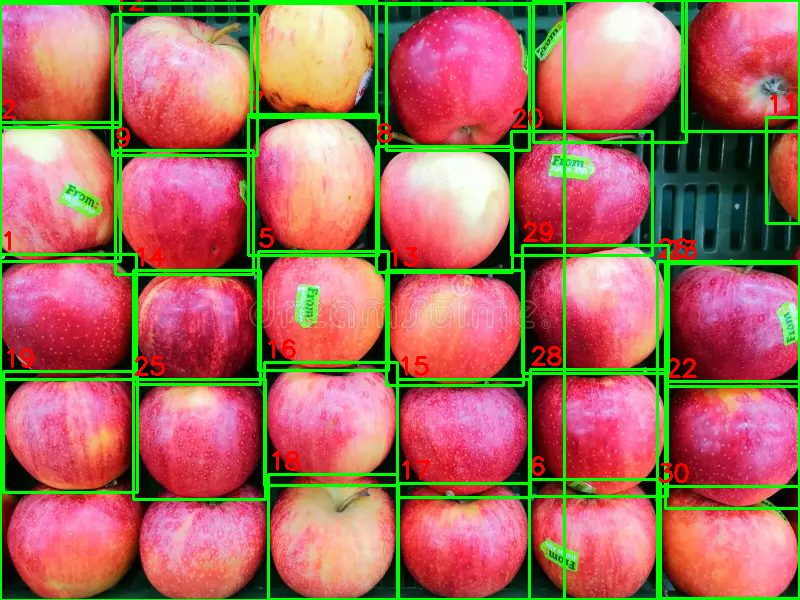

In [ ]:
REFERENCE_CLASS_NAME = 'bottle'
REAL_WIDTH_CM = 6.5

# Upload image
print("Upload image:")
uploaded = files.upload()

for filename in uploaded.keys():
    img = cv2.imread(filename)
    results = model(img)

    pixels_per_metric = None
    detections = []

    # -------- First Pass: Calibration --------
    for r in results:
        for box in r.boxes:
            cls_id = int(box.cls[0])
            label = model.names[cls_id]

            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
            w_px = x2 - x1

            detections.append((label, x1, y1, x2, y2, w_px))

            if label == REFERENCE_CLASS_NAME and pixels_per_metric is None:
                pixels_per_metric = w_px / REAL_WIDTH_CM
                print(f"✅ Calibration using {label}")

    if pixels_per_metric is None:
        print("⚠️ No reference → using default scale")
        pixels_per_metric = 10.0

    # -------- Second Pass: Objects --------
    object_count = 0
    object_measurements = []

    for label, x1, y1, x2, y2, w_px in detections:

        # ✅ Detect ALL objects except reference (optional)
        if label != REFERENCE_CLASS_NAME:

            object_count += 1

            h_px = y2 - y1
            width_cm = w_px / pixels_per_metric
            height_cm = h_px / pixels_per_metric

            object_measurements.append((width_cm, height_cm))

            # Draw bounding box
            cv2.rectangle(img,
                          (int(x1), int(y1)),
                          (int(x2), int(y2)),
                          (0, 255, 0), 2)

            # Draw object number
            cv2.putText(img,
                        str(object_count),
                        (int(x1), int(y1) - 5),
                        cv2.FONT_HERSHEY_SIMPLEX,
                        0.8,
                        (0, 0, 255),
                        2)

    # -------- Print Output --------
    print("\n==============================")
    print(f"Total Objects Detected: {object_count}")
    print("==============================")

    for i, (w, h) in enumerate(object_measurements, start=1):
        print(f"Object {i}: {w:.2f}cm x {h:.2f}cm")

    # Show image
    cv2_imshow(img)

Upload image:


Saving OIP (6).jpg to OIP (6) (3).jpg

0: 448x640 22 oranges, 12.9ms
Speed: 2.4ms preprocess, 12.9ms inference, 1.6ms postprocess per image at shape (1, 3, 448, 640)
⚠️ No reference → using default scale

Total Objects Detected: 22
Object 1: 5.11cm x 5.04cm
Object 2: 5.34cm x 4.65cm
Object 3: 4.89cm x 4.38cm
Object 4: 4.93cm x 4.57cm
Object 5: 5.22cm x 4.46cm
Object 6: 5.04cm x 4.03cm
Object 7: 4.78cm x 3.92cm
Object 8: 26.85cm x 16.98cm
Object 9: 4.98cm x 4.03cm
Object 10: 5.10cm x 4.60cm
Object 11: 1.19cm x 3.58cm
Object 12: 5.03cm x 4.07cm
Object 13: 3.17cm x 5.20cm
Object 14: 5.16cm x 4.30cm
Object 15: 4.19cm x 4.01cm
Object 16: 5.29cm x 4.51cm
Object 17: 5.48cm x 4.50cm
Object 18: 3.97cm x 4.49cm
Object 19: 5.04cm x 4.03cm
Object 20: 4.42cm x 3.96cm
Object 21: 5.21cm x 3.91cm
Object 22: 4.93cm x 3.91cm


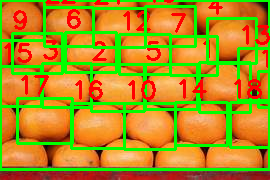

In [ ]:
REFERENCE_CLASS_NAME = 'bottle'
REAL_WIDTH_CM = 6.5

# Upload image
print("Upload image:")
uploaded = files.upload()

for filename in uploaded.keys():
    img = cv2.imread(filename)
    results = model(img)

    pixels_per_metric = None
    detections = []

    # -------- First Pass: Calibration --------
    for r in results:
        for box in r.boxes:
            cls_id = int(box.cls[0])
            label = model.names[cls_id]

            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
            w_px = x2 - x1

            detections.append((label, x1, y1, x2, y2, w_px))

            if label == REFERENCE_CLASS_NAME and pixels_per_metric is None:
                pixels_per_metric = w_px / REAL_WIDTH_CM
                print(f"✅ Calibration using {label}")

    if pixels_per_metric is None:
        print("⚠️ No reference → using default scale")
        pixels_per_metric = 10.0

    # -------- Second Pass: Objects --------
    object_count = 0
    object_measurements = []

    for label, x1, y1, x2, y2, w_px in detections:

        # ✅ Detect ALL objects except reference (optional)
        if label != REFERENCE_CLASS_NAME:

            object_count += 1

            h_px = y2 - y1
            width_cm = w_px / pixels_per_metric
            height_cm = h_px / pixels_per_metric

            object_measurements.append((width_cm, height_cm))

            # Draw bounding box
            cv2.rectangle(img,
                          (int(x1), int(y1)),
                          (int(x2), int(y2)),
                          (0, 255, 0), 2)

            # Draw object number
            cv2.putText(img,
                        str(object_count),
                        (int(x1), int(y1) - 5),
                        cv2.FONT_HERSHEY_SIMPLEX,
                        0.8,
                        (0, 0, 255),
                        2)

    # -------- Print Output --------
    print("\n==============================")
    print(f"Total Objects Detected: {object_count}")
    print("==============================")

    for i, (w, h) in enumerate(object_measurements, start=1):
        print(f"Object {i}: {w:.2f}cm x {h:.2f}cm")

    # Show image
    cv2_imshow(img)